# 01 — Pipeline: EDA + Pre-processamento (+ proximas partes)

**Tech Challenge Fase 1 — G17**

| Parte | Responsavel | Foco |
|-------|-------------|------|
| **A** | **Luis Conrado** | Dataset, contexto e EDA |
| **B** | **Beatriz Honey** | Encoding, correlacao, split, scaler e pipeline |
| **C** | **Pedro Henrique Klein** | Modelagem (>= 2 algoritmos de classificacao) |
| **D** | **Rodrigo Edson Fernandes** | Avaliacao, metricas e explicabilidade (SHAP) |
| **E** | **Alexandre Akio** | Integracao, documentacao, PDF e video |

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — arquivo `data/raw/data.csv`

Fluxo unico no notebook. Partes A e B prontas; C–E sao as proximas entregas do grupo.


## Parte A — Contexto e EDA

**Responsável:** Luis Conrado

### A1. Contexto do problema

O câncer de mama está entre os **tipos de câncer** mais frequentes em mulheres. O **diagnóstico precoce** melhora o prognóstico e reduz a mortalidade.

Neste projeto, usamos features numéricas extraídas de imagens de **FNA** (*Fine Needle Aspiration* — aspiração por agulha fina) de uma massa mamária. Cada feature descreve características do **núcleo celular** (tamanho, textura, irregularidade da borda etc.).

O objetivo do modelo é apoiar a classificação **maligno (M) vs benigno (B)**.

> **Importante:** o sistema de IA **apoia** a decisão do profissional de saúde — **nunca a substitui**. Em contexto clínico, um falso negativo costuma ser mais grave que um falso positivo; por isso priorizamos o **recall da classe maligna** (capacidade de detectar os casos malignos).


### A2. Setup

Rode as células de cima para baixo. Esta célula precisa rodar antes das demais.


In [19]:
# --- Setup: importa bibliotecas e define caminhos do projeto ---
from pathlib import Path

import pandas as pd              # tabelas / CSV
import numpy as np               # calculos numericos
import matplotlib.pyplot as plt  # graficos base
import seaborn as sns            # graficos estatisticos

# Pre-processamento (usado na Parte B)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# estilo visual padrao dos graficos
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

# caminhos relativos a pasta notebooks/
ROOT = Path("..").resolve()                   # raiz do repositorio
RAW_CSV = ROOT / "data" / "raw" / "data.csv"  # dataset baixado do Kaggle
FIG_DIR = ROOT / "reports" / "figuras"        # onde salvar as imagens
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Raiz:", ROOT)
print("CSV:", RAW_CSV, "| existe:", RAW_CSV.exists())
print("Figuras:", FIG_DIR)
print("Libs OK")


Raiz: C:\Users\Conrado\Documents\FIAP\TECH-CHANLLEENGE\tech-challenge-fase1-g17
CSV: C:\Users\Conrado\Documents\FIAP\TECH-CHANLLEENGE\tech-challenge-fase1-g17\data\raw\data.csv | existe: True
Figuras: C:\Users\Conrado\Documents\FIAP\TECH-CHANLLEENGE\tech-challenge-fase1-g17\reports\figuras
Libs OK


### A3. Carregar o dataset

Carga unica a partir de `data/raw/data.csv` (padrao do repositorio).


In [20]:
# --- Carrega o CSV e remove coluna vazia tipica do Kaggle ---
df = pd.read_csv(RAW_CSV)  # dataframe principal

# no CSV do Kaggle costuma existir uma coluna vazia chamada Unnamed: 32
unnamed = [c for c in df.columns if str(c).startswith("Unnamed")]
if unnamed:
    print("Nulos nas colunas Unnamed:", {c: int(df[c].isna().sum()) for c in unnamed})
    df = df.drop(columns=unnamed)
    print("Removidas colunas vazias:", unnamed)

print(f"Shape: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()  # mostra as primeiras linhas


Nulos nas colunas Unnamed: {'Unnamed: 32': 569}
Removidas colunas vazias: ['Unnamed: 32']
Shape: 569 linhas x 32 colunas


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### A4. Descricao das colunas

Fonte: [Kaggle — Breast Cancer Wisconsin](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data).

Ha **10 medidas** do nucleo celular, cada uma em 3 formas: `*_mean`, `*_se` e `*_worst`.


In [21]:
# --- Glossario das features (texto util para o relatorio) ---
glossario = pd.DataFrame([
    {"coluna_ou_grupo": "id", "descricao": "Identificador da amostra (nao usar no modelo)"},
    {"coluna_ou_grupo": "diagnosis", "descricao": "Alvo: M = maligno, B = benigno"},
    {"coluna_ou_grupo": "radius", "descricao": "Media das distancias do centro aos pontos do perimetro"},
    {"coluna_ou_grupo": "texture", "descricao": "Desvio padrao dos valores de escala de cinza"},
    {"coluna_ou_grupo": "perimeter", "descricao": "Perimetro da celula"},
    {"coluna_ou_grupo": "area", "descricao": "Area da celula"},
    {"coluna_ou_grupo": "smoothness", "descricao": "Variacao local nos comprimentos de raio"},
    {"coluna_ou_grupo": "compactness", "descricao": "perimeter^2 / area - 1.0"},
    {"coluna_ou_grupo": "concavity", "descricao": "Severidade de porcoes concavas do contorno"},
    {"coluna_ou_grupo": "concave points", "descricao": "Numero de porcoes concavas do contorno"},
    {"coluna_ou_grupo": "symmetry", "descricao": "Simetria"},
    {"coluna_ou_grupo": "fractal_dimension", "descricao": "Complexidade fractal da borda"},
])
glossario


,coluna_ou_grupo,descricao
0,id,Identificador da amostra (nao usar no modelo)
1,diagnosis,"Alvo: M = maligno, B = benigno"
2,radius,Media das distancias do centro aos pontos do p...
3,texture,Desvio padrao dos valores de escala de cinza
4,perimeter,Perimetro da celula
5,area,Area da celula
6,smoothness,Variacao local nos comprimentos de raio
7,compactness,perimeter^2 / area - 1.0
8,concavity,Severidade de porcoes concavas do contorno
9,concave points,Numero de porcoes concavas do contorno


In [22]:
# --- Lista colunas e tipos de dados ---
print("Colunas do CSV:")
print(list(df.columns))
print()
df.info()  # tipos, nulos e uso de memoria


Colunas do CSV:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64


### A5. Qualidade dos dados


In [23]:
# --- Qualidade: nulos, duplicatas e estatisticas descritivas ---
missing = df.isna().sum()
qualidade = pd.DataFrame({
    "nulos": missing,
    "pct_nulos": (missing / len(df) * 100).round(2),
})
qualidade = qualidade[qualidade["nulos"] > 0]  # so colunas com algum nulo

print(f"Linhas duplicadas: {df.duplicated().sum()}")
if qualidade.empty:
    print("Nenhum valor nulo encontrado nas colunas restantes.")
else:
    display(qualidade)

df.describe().T  # media, desvio, min, max etc. (transposto para ler melhor)


Linhas duplicadas: 0
Nenhum valor nulo encontrado nas colunas restantes.


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


### A6. Balanceamento da variavel alvo (`diagnosis`)


,contagem,percentual_%
diagnosis,,
B,357,62.74
M,212,37.26


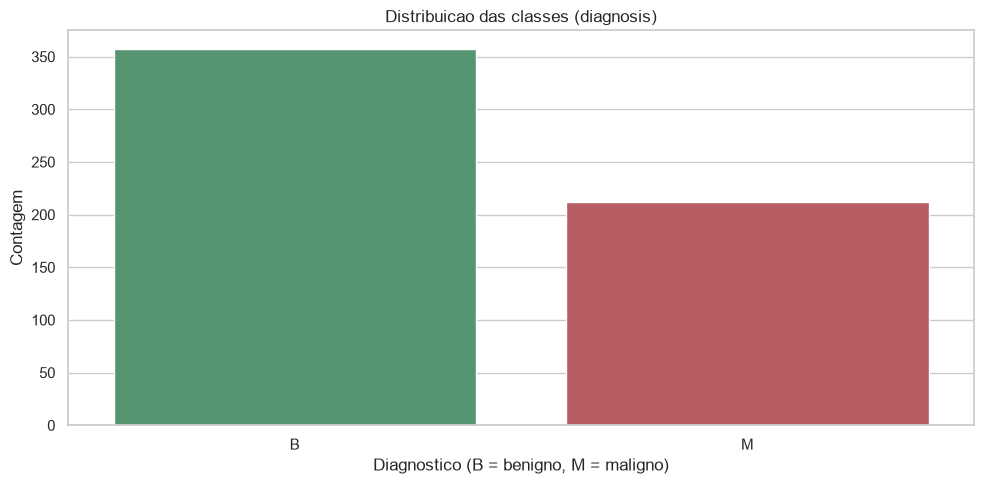

Salvo: C:\Users\Conrado\Documents\FIAP\TECH-CHANLLEENGE\tech-challenge-fase1-g17\reports\figuras\01_balanceamento_classes.png


In [24]:
# --- Balanceamento da classe alvo (M vs B) ---
contagem = df["diagnosis"].value_counts()
percentual = (df["diagnosis"].value_counts(normalize=True) * 100).round(2)
display(pd.DataFrame({"contagem": contagem, "percentual_%": percentual}))

# grafico de barras das classes
fig, ax = plt.subplots()
sns.countplot(
    data=df,
    x="diagnosis",
    order=["B", "M"],
    hue="diagnosis",
    palette={"B": "#4C9F70", "M": "#C44E52"},  # verde=benigno, vermelho=maligno
    legend=False,
    ax=ax,
)
ax.set_title("Distribuicao das classes (diagnosis)")
ax.set_xlabel("Diagnostico (B = benigno, M = maligno)")
ax.set_ylabel("Contagem")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_balanceamento_classes.png", dpi=150)  # exporta para o relatorio
plt.show()
print("Salvo:", FIG_DIR / "01_balanceamento_classes.png")


### A7. Distribuicoes e boxplots (`*_mean`)


Features plotadas: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean']


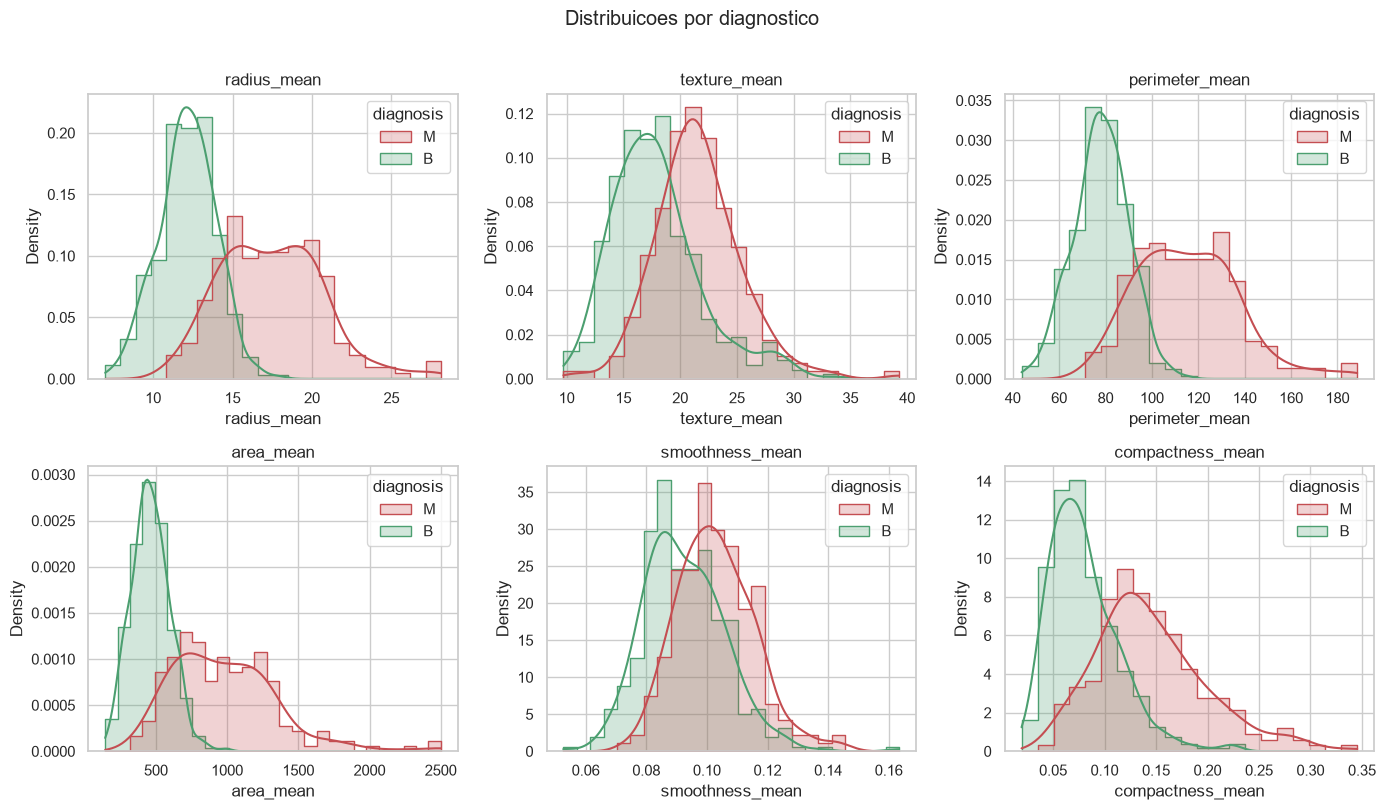

Salvo: C:\Users\Conrado\Documents\FIAP\TECH-CHANLLEENGE\tech-challenge-fase1-g17\reports\figuras\02_distribuicoes_features.png


In [25]:
# --- Distribuicoes das principais features *_mean por diagnostico ---
feature_cols = [c for c in df.columns if c not in {"id", "diagnosis"}]
mean_cols = [c for c in feature_cols if c.endswith("_mean")][:6]  # 6 primeiras para visualizacao
print("Features plotadas:", mean_cols)

n = len(mean_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).ravel()

for i, col in enumerate(mean_cols):
    # histograma + densidade, separado por M e B
    sns.histplot(
        data=df,
        x=col,
        hue="diagnosis",
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[i],
        palette={"B": "#4C9F70", "M": "#C44E52"},
    )
    axes[i].set_title(col)

# esconde eixos vazios (se sobrar espaco no grid)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribuicoes por diagnostico", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_distribuicoes_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo:", FIG_DIR / "02_distribuicoes_features.png")


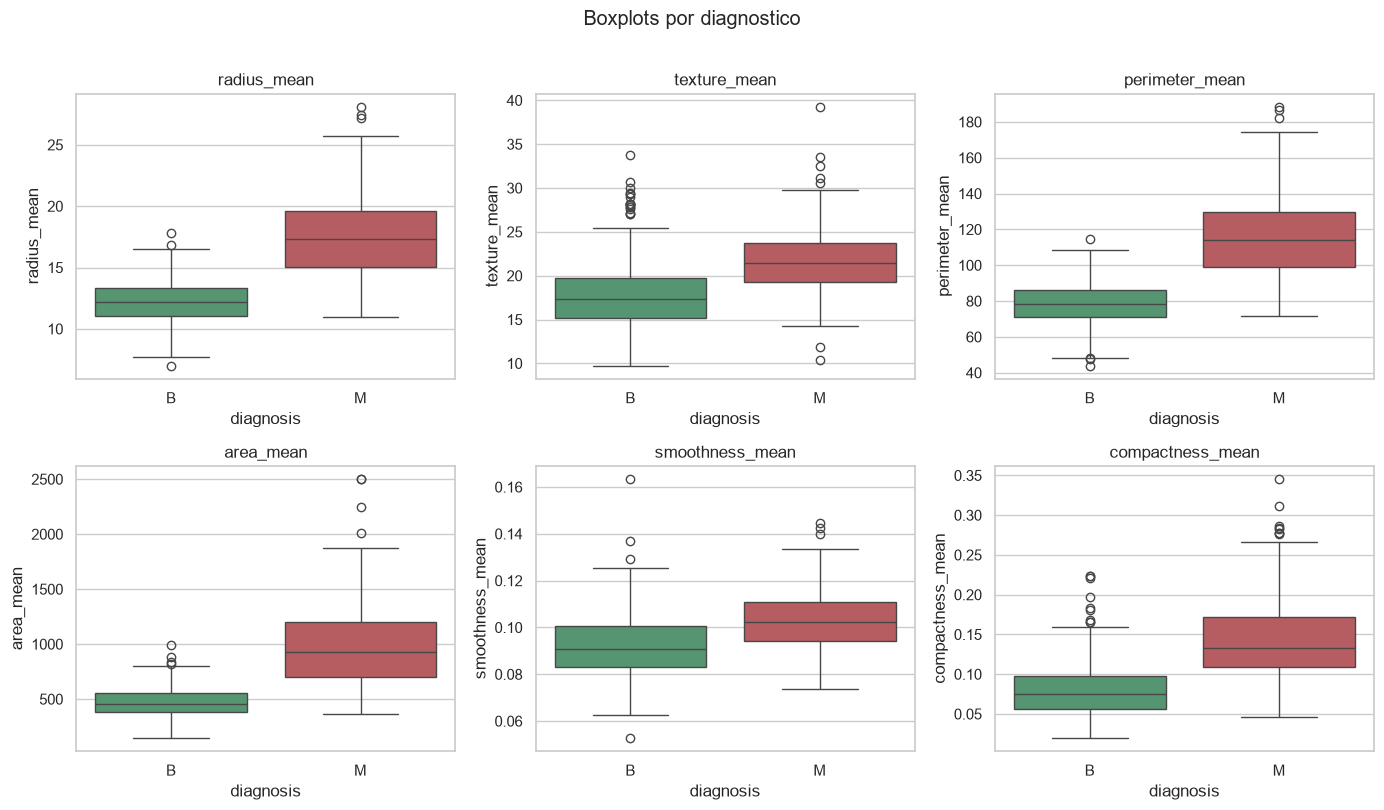

Salvo: C:\Users\Conrado\Documents\FIAP\TECH-CHANLLEENGE\tech-challenge-fase1-g17\reports\figuras\03_boxplots_features.png


In [26]:
# --- Boxplots: compara mediana e outliers entre B e M ---
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).ravel()

for i, col in enumerate(mean_cols):
    sns.boxplot(
        data=df,
        x="diagnosis",
        y=col,
        order=["B", "M"],
        hue="diagnosis",
        palette={"B": "#4C9F70", "M": "#C44E52"},
        legend=False,
        ax=axes[i],
    )
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Boxplots por diagnostico", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_boxplots_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo:", FIG_DIR / "03_boxplots_features.png")


### A8. Correlacao preliminar (`*_mean`)

Visao inicial da EDA. A analise completa e multicolinearidade ficam na Parte B.


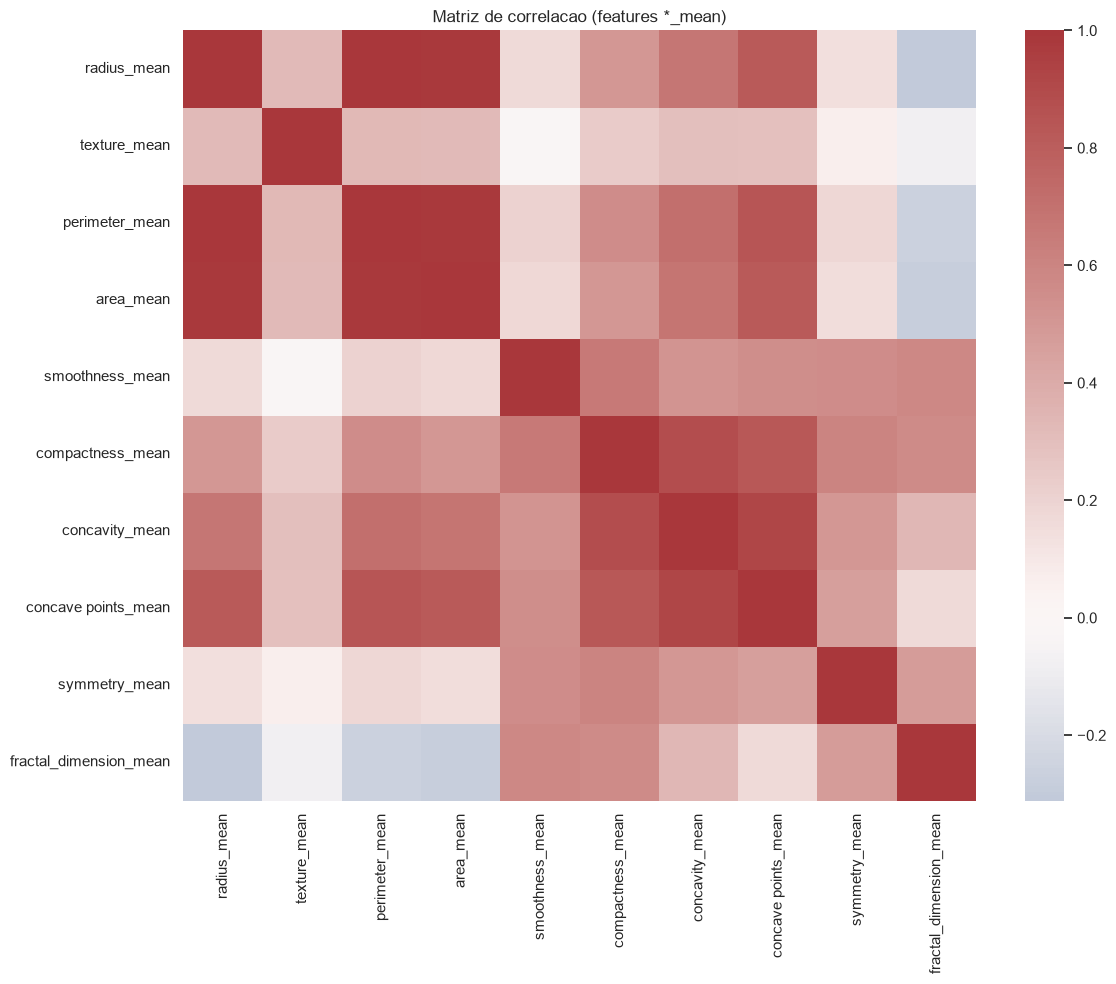

Salvo: C:\Users\Conrado\Documents\FIAP\TECH-CHANLLEENGE\tech-challenge-fase1-g17\reports\figuras\04_correlacao_subset.png


In [27]:
# --- Correlacao preliminar entre features *_mean (visao da EDA) ---
# Obs.: analise profunda de multicolinearidade fica com a Parte B
subset = [c for c in feature_cols if c.endswith("_mean")]
corr_mean = df[subset].corr()  # matriz de correlacao de Pearson

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_mean, cmap="vlag", center=0, annot=False, ax=ax)
ax.set_title("Matriz de correlacao (features *_mean)")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_correlacao_subset.png", dpi=150)
plt.show()
print("Salvo:", FIG_DIR / "04_correlacao_subset.png")


### A9. Insights iniciais (EDA) — Luis Conrado

- Base com ~569 amostras e dezenas de features numericas de FNA.
- Classes `B`/`M` com desbalanceamento leve (mais benignos).
- Features de tamanho e irregularidade tendem a ser maiores em malignos.
- Ha correlacao alta entre features de tamanho — tratar na Parte B / modelagem.


---

## Parte B — Pre-processamento

**Responsavel:** Beatriz Honey

Etapas: limpeza final (`id`), encoding, correlacao completa, split estratificado, escalonamento via `Pipeline`.


### B1. Remover `id` (sem valor preditivo)


In [10]:
# --- Remove id: identificador sem valor preditivo para o modelo ---
cols_drop = [c for c in ["id"] if c in df.columns]
if cols_drop:
    df = df.drop(columns=cols_drop)
    print("Removidas:", cols_drop)
else:
    print("Coluna id ja ausente.")

print("Shape atual:", df.shape)


Removidas: ['id']
Shape atual: (569, 31)


### B2. Encoding do alvo

Mapeamento: **B = 0** (benigno), **M = 1** (maligno).


In [11]:
# --- Encoding: transforma diagnosis de texto (M/B) para numero (1/0) ---
print("Classes originais:", df["diagnosis"].unique())
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})
print("Contagem apos encoding:")
print(df["diagnosis"].value_counts().to_string())
print("Proporcao (%):")
print((df["diagnosis"].value_counts(normalize=True) * 100).round(2).to_string())


Classes originais: <StringArray>
['M', 'B']
Length: 2, dtype: str
Contagem apos encoding:
diagnosis
0    357
1    212
Proporcao (%):
diagnosis
0    62.74
1    37.26


### B3. Correlacao completa, vs alvo e multicolinearidade


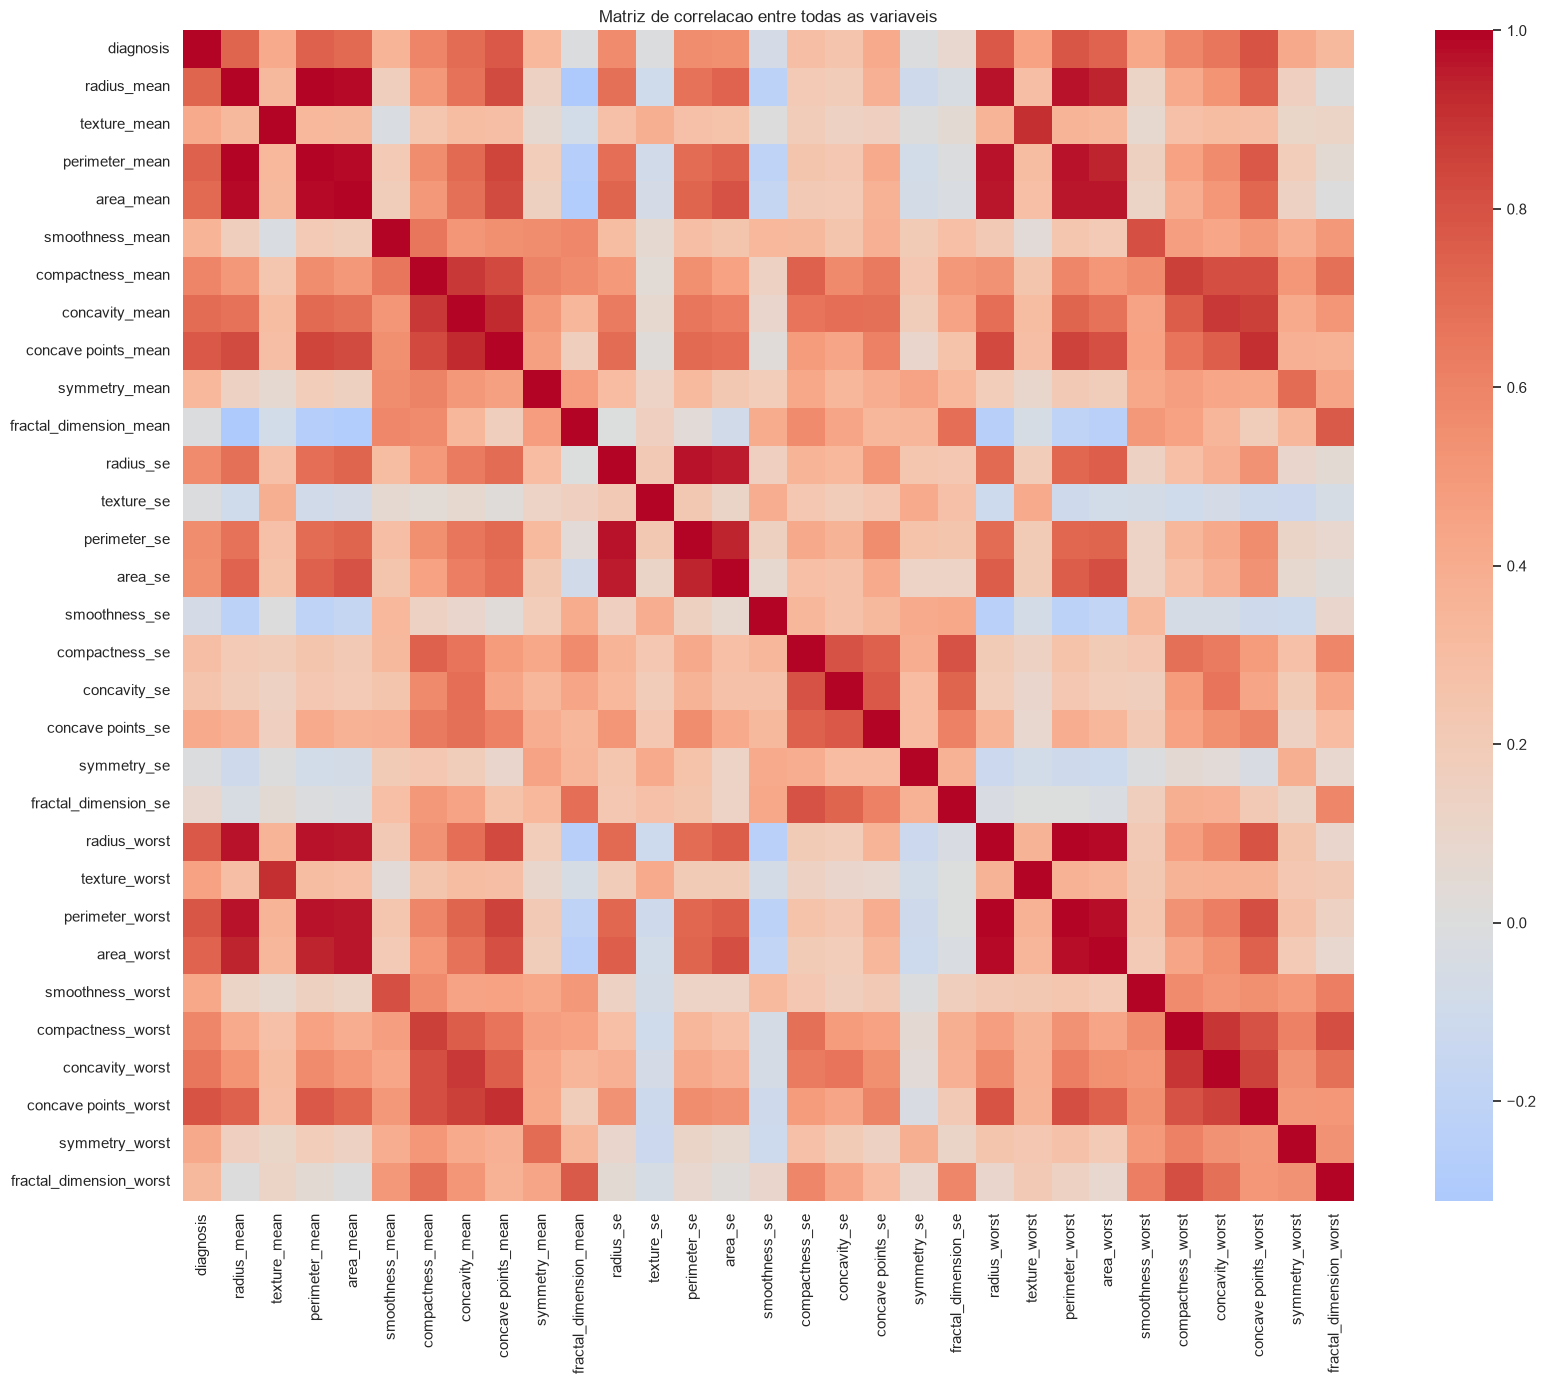

In [12]:
# --- Heatmap completo (todas as variaveis numericas, ja com alvo 0/1) ---
corr_matrix = df.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Matriz de correlacao entre todas as variaveis")
plt.tight_layout()
plt.show()


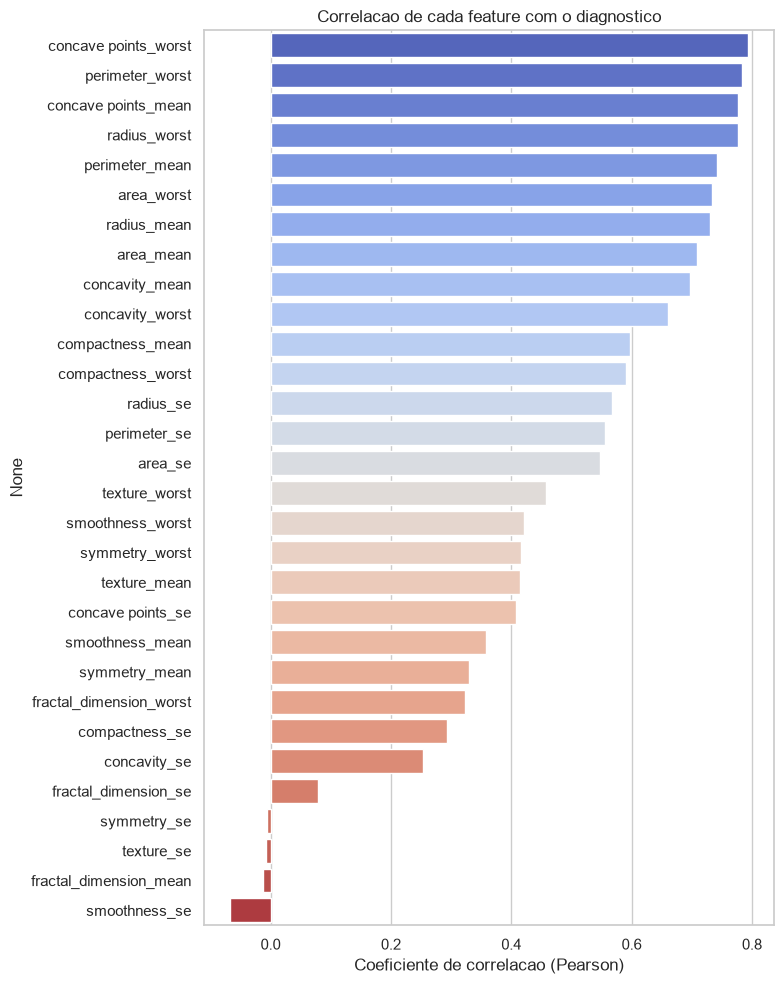

Top 5 features mais correlacionadas com o diagnostico:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636


In [13]:
# --- Correlacao de cada feature com o alvo (diagnosis), ordenada ---
corr_target = corr_matrix["diagnosis"].drop("diagnosis").sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(
    x=corr_target.values,
    y=corr_target.index,
    hue=corr_target.index,
    palette="coolwarm",
    legend=False,
)
plt.title("Correlacao de cada feature com o diagnostico")
plt.xlabel("Coeficiente de correlacao (Pearson)")
plt.tight_layout()
plt.show()

print("Top 5 features mais correlacionadas com o diagnostico:")
print(corr_target.head(5).to_string())


In [14]:
# --- Pares com correlacao > 0.9 (sinal de multicolinearidade) ---
# Pegamos so o triangulo superior para nao repetir pares (A,B) e (B,A)
features_corr = df.drop(columns=["diagnosis"]).corr().abs()
upper = features_corr.where(np.triu(np.ones(features_corr.shape), k=1).astype(bool))

pares = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlacao"})
)
pares = pares[pares["correlacao"] > 0.9].sort_values("correlacao", ascending=False)

print(f"Numero de pares com correlacao > 0.9: {len(pares)}")
pares.head(15)


Numero de pares com correlacao > 0.9: 21


,feature_1,feature_2,correlacao
2,radius_mean,perimeter_mean,0.997855
622,radius_worst,perimeter_worst,0.993708
3,radius_mean,area_mean,0.987357
63,perimeter_mean,area_mean,0.986507
623,radius_worst,area_worst,0.984015
683,perimeter_worst,area_worst,0.977578
312,radius_se,perimeter_se,0.972794
82,perimeter_mean,perimeter_worst,0.970387
20,radius_mean,radius_worst,0.969539
80,perimeter_mean,radius_worst,0.969476


**Observacao (Beatriz Honey):** medidas como `radius`, `perimeter` e `area` (mean/se/worst) costumam ser altamente correlacionadas. A remocao de redundantes ou PCA pode ser revisitada na modelagem, conforme o algoritmo.


### B4. Split treino/teste estratificado


In [15]:
# --- Split 80/20 com stratify (mantem proporcao de M/B em treino e teste) ---
X = df.drop(columns=["diagnosis"])  # features
y = df["diagnosis"]                 # alvo

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,  # reprodutibilidade
    stratify=y,       # evita distorcer o balanceamento nos conjuntos
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print("Proporcao treino:")
print(y_train.value_counts(normalize=True).round(3).to_string())
print("Proporcao teste:")
print(y_test.value_counts(normalize=True).round(3).to_string())


Treino: 455 amostras | Teste: 114 amostras
Proporcao treino:
diagnosis
0    0.626
1    0.374
Proporcao teste:
diagnosis
0    0.632
1    0.368


### B5. Pipeline de escalonamento (`StandardScaler`)

Fit **somente** no treino; no teste apenas `transform` (evita leakage).


In [16]:
# --- Pipeline de pre-processamento: aprende escala so no treino ---
preprocessing_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),  # media 0 e desvio 1
])

# fit_transform no treino; transform no teste (mesmos parametros)
X_train_processed = preprocessing_pipeline.fit_transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

# volta para DataFrame para inspecionar com facilidade
X_train_processed = pd.DataFrame(X_train_processed, columns=X_train.columns, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=X_test.columns, index=X_test.index)

print("Antes (treino) — mean/std de algumas features:")
print(X_train.describe().loc[["mean", "std"]].T.head())
print()
print("Depois (treino) — mean/std:")
print(X_train_processed.describe().loc[["mean", "std"]].T.head())


Antes (treino) — mean/std de algumas features:
                       mean         std
radius_mean       14.166077    3.579081
texture_mean      19.417692    4.290653
perimeter_mean    92.215868   24.717118
area_mean        659.578242  360.418686
smoothness_mean    0.095993    0.014310

Depois (treino) — mean/std:
                         mean       std
radius_mean     -1.737316e-16  1.001101
texture_mean     3.904081e-16  1.001101
perimeter_mean   4.704418e-16  1.001101
area_mean       -1.171224e-16  1.001101
smoothness_mean  7.242070e-16  1.001101


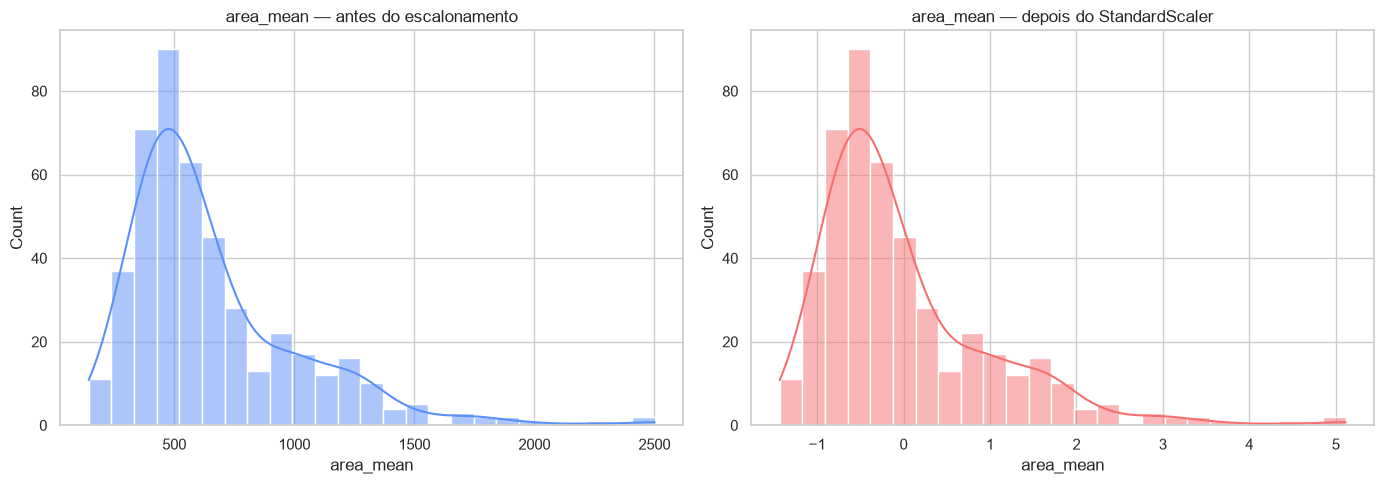

In [17]:
# --- Visual: distribuicao de area_mean antes x depois do StandardScaler ---
# O formato da distribuicao nao muda — so a escala do eixo X
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(X_train["area_mean"], kde=True, ax=axes[0], color="#5B8FF9")
axes[0].set_title("area_mean — antes do escalonamento")

sns.histplot(X_train_processed["area_mean"], kde=True, ax=axes[1], color="#F76E6E")
axes[1].set_title("area_mean — depois do StandardScaler")

plt.tight_layout()
plt.show()


### B6. Resumo final — Beatriz Honey

| Item | Descricao |
|------|-----------|
| `X_train_processed` / `X_test_processed` | Features limpas e escalonadas |
| `y_train` / `y_test` | Alvo (0 = Benigno, 1 = Maligno) |
| `preprocessing_pipeline` | Pipeline ajustado no treino |

**Proximos passos:** Parte C (Pedro H Klein) — modelagem; Parte D (Rodrigo EF) — metricas/SHAP; Parte E (Alexandre Akio) — PDF/video/README.


In [18]:
# --- Inspecao rapida do resultado do pre-processamento ---
print("=== RESUMO PIPELINE ===")
print(f"Features: {X_train_processed.shape[1]}")
print(f"Treino processado: {X_train_processed.shape}")
print(f"Teste processado:  {X_test_processed.shape}")
X_train_processed.head()


=== RESUMO PIPELINE ===
Features: 30
Treino processado: (455, 30)
Teste processado:  (114, 30)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
10,0.518559,0.891826,0.424632,0.383925,-0.974744,-0.689772,-0.688586,-0.398175,-1.039155,-0.825056,-0.109318,-0.055976,-0.210096,-0.015913,-1.005184,-0.911942,-0.662816,-0.652561,-0.701889,-0.275394,0.579798,1.313242,0.466908,0.445983,-0.596155,-0.634722,-0.610227,-0.235744,0.054566,0.021837
170,-0.516364,-1.639710,-0.541349,-0.542961,0.476219,-0.631834,-0.604281,-0.303075,0.521543,-0.454523,-0.604378,-1.001046,-0.585429,-0.493454,0.403212,-0.768173,-0.479187,0.114508,-0.142951,-0.577398,-0.582459,-1.690291,-0.611934,-0.587014,0.273582,-0.814844,-0.712666,-0.323208,-0.137576,-0.904402
407,-0.368118,0.455515,-0.388250,-0.402970,-1.432979,-0.383927,-0.342175,-0.765459,-0.850857,-0.226171,0.303980,1.051501,-0.169545,-0.000809,-0.310104,1.106330,0.622585,0.273685,0.754483,1.508105,-0.398622,0.181977,-0.475431,-0.420778,-1.622785,-0.391399,-0.431313,-0.890825,-0.675893,-0.144016
430,0.205285,0.726168,0.400330,0.070612,0.243253,2.203585,2.256094,1.213233,0.818474,0.899791,-0.545730,-0.621677,0.261427,-0.353585,0.024460,2.090728,1.490561,1.695127,-0.654909,0.767548,-0.000309,0.274191,0.513776,-0.099482,0.418538,2.865970,2.958619,1.977064,-0.075646,1.728848
27,1.243005,0.194195,1.210377,1.206652,-0.111442,0.051348,0.732962,0.713767,-0.427187,-0.822184,1.523863,1.143941,1.282748,1.081313,1.351845,0.107731,0.592927,1.180988,0.301550,0.171527,1.012835,0.223144,0.938517,0.880910,0.073201,-0.277006,0.327775,0.501859,-0.909322,-0.546249


---

## Parte C — Modelagem

**Responsavel:** Pedro Henrique Klein

Nesta parte usei os dados que ja vieram do pre-processamento da Parte B. A ideia foi testar alguns algoritmos diferentes e comparar os resultados com **validacao cruzada** e tambem com uma validacao simples separada do treino.

Como o problema e de diagnostico, olhei principalmente para o **recall da classe maligna (1)**, porque errar um caso maligno como benigno seria o pior cenario.


### C1. Importar modelos e metricas

Modelos escolhidos:

- **Regressao Logistica:** modelo linear simples, bom para baseline.
- **KNN:** classifica pela proximidade entre amostras.
- **SVM:** costuma funcionar bem com dados escalonados.
- **Arvore de Decisao:** modelo facil de interpretar.
- **Random Forest:** combina varias arvores e geralmente melhora a estabilidade.
- **Naive Bayes:** modelo probabilistico simples, bom para comparar.


In [ ]:
# --- Modelagem: imports usados nesta parte ---
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


### C2. Criar a lista de modelos

Aqui ficam os algoritmos que serao comparados. Usei modelos classicos do `scikit-learn`, sem muitos ajustes manuais para manter simples.


In [ ]:
# --- Lista de modelos para testar ---
modelos = {
    "Regressao Logistica": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf", random_state=42),
    "Arvore de Decisao": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42),
    "Naive Bayes": GaussianNB(),
}

print("Modelos que serao testados:")
for nome in modelos:
    print("-", nome)


### C3. Validacao cruzada com Pipeline

Nesta etapa usei `Pipeline` com `StandardScaler` + modelo. Assim, em cada fold da validacao cruzada, o scaler aprende somente com o treino daquele fold.

Usei `StratifiedKFold` para manter a proporcao de benignos e malignos parecida em cada divisao.


In [ ]:
# --- Validacao cruzada: Pipeline(StandardScaler + modelo) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metricas = {
    "accuracy": "accuracy",
    "precision_maligno": "precision",
    "recall_maligno": "recall",
    "f1_maligno": "f1",
}

resultados_cv = []
pipelines_cv = {}

for nome, modelo in modelos.items():
    pipeline_modelo = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("modelo", modelo),
    ])

    scores = cross_validate(
        pipeline_modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=metricas,
    )

    resultados_cv.append({
        "modelo": nome,
        "accuracy_media": scores["test_accuracy"].mean(),
        "precision_maligno_media": scores["test_precision_maligno"].mean(),
        "recall_maligno_media": scores["test_recall_maligno"].mean(),
        "f1_maligno_media": scores["test_f1_maligno"].mean(),
    })

    pipelines_cv[nome] = pipeline_modelo

comparacao_cv = pd.DataFrame(resultados_cv)
comparacao_cv = comparacao_cv.sort_values(
    by=["recall_maligno_media", "f1_maligno_media", "accuracy_media"],
    ascending=False,
).reset_index(drop=True)

comparacao_cv


### C4. Separar treino e validacao simples

A validacao cruzada acima e a comparacao principal. Mesmo assim, deixei uma divisao simples treino/validacao para conferir o comportamento dos modelos em um conjunto separado.


In [ ]:
# --- Separacao treino/validacao dentro do conjunto de treino ---
X_treino_modelo, X_validacao, y_treino_modelo, y_validacao = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train,
)

print("Treino dos modelos:", X_treino_modelo.shape)
print("Validacao:", X_validacao.shape)
print("Proporcao da validacao:")
print(y_validacao.value_counts(normalize=True).round(3).to_string())


### C5. Conferir modelos na validacao simples

Aqui os modelos treinam em `X_treino_modelo` e sao comparados em `X_validacao`. Esta parte serve como uma segunda checagem, sem usar o teste final.


In [ ]:
# --- Comparacao simples em treino/validacao ---
resultados_validacao = []
modelos_treinados = {}

for nome, modelo in modelos.items():
    modelo.fit(X_treino_modelo, y_treino_modelo)
    pred_validacao = modelo.predict(X_validacao)

    resultados_validacao.append({
        "modelo": nome,
        "accuracy": accuracy_score(y_validacao, pred_validacao),
        "precision_maligno": precision_score(y_validacao, pred_validacao),
        "recall_maligno": recall_score(y_validacao, pred_validacao),
        "f1_maligno": f1_score(y_validacao, pred_validacao),
    })

    modelos_treinados[nome] = modelo

comparacao_modelos = pd.DataFrame(resultados_validacao)
comparacao_modelos = comparacao_modelos.sort_values(
    by=["recall_maligno", "f1_maligno", "accuracy"],
    ascending=False,
).reset_index(drop=True)

comparacao_modelos


### C6. Comparacao visual da validacao cruzada

O grafico abaixo compara as medias da validacao cruzada. Para este problema, o recall da classe maligna tem peso maior na escolha.


In [ ]:
# --- Grafico simples das metricas medias na validacao cruzada ---
comparacao_cv_plot = comparacao_cv.melt(
    id_vars="modelo",
    value_vars=["accuracy_media", "precision_maligno_media", "recall_maligno_media", "f1_maligno_media"],
    var_name="metrica",
    value_name="valor",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=comparacao_cv_plot, x="valor", y="modelo", hue="metrica")
plt.title("Comparacao dos modelos na validacao cruzada")
plt.xlabel("Media da metrica nos folds")
plt.ylabel("Modelo")
plt.xlim(0, 1.05)
plt.legend(title="Metrica", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### C7. Escolha do melhor modelo

O melhor modelo foi escolhido pela tabela de **validacao cruzada**, primeiro pelo recall medio da classe maligna, depois pelo F1 medio e accuracy media como desempate.


In [ ]:
# --- Escolha automatica do melhor modelo pela validacao cruzada ---
melhor_linha = comparacao_cv.iloc[0]
nome_melhor_modelo = melhor_linha["modelo"]

print("Melhor modelo na validacao cruzada:", nome_melhor_modelo)
print(melhor_linha.to_string())

# Matriz de confusao na validacao simples, so para conferir os erros antes da avaliacao final
pred_melhor_validacao = modelos_treinados[nome_melhor_modelo].predict(X_validacao)
cm_validacao = confusion_matrix(y_validacao, pred_melhor_validacao)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_validacao,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"],
)
plt.title(f"Matriz de confusao - validacao ({nome_melhor_modelo})")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


### C8. Treinar modelo final

Depois de escolher o algoritmo, treino novamente usando todo o conjunto de treino original (`X_train`). O `modelo_final` ja inclui o `StandardScaler`, entao ele pode receber dados sem escalonar.


In [ ]:
# --- Modelo final treinado com todo o treino da Parte B ---
modelo_final = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("modelo", modelos[nome_melhor_modelo]),
])

modelo_final.fit(X_train, y_train)

print("Modelo final treinado:", nome_melhor_modelo)
print("Usado para treinar:", X_train.shape[0], "amostras")
print("Teste ainda separado para avaliacao final:", X_test.shape[0], "amostras")


### C9. Matriz de confusao e classification report

Depois de treinar o `modelo_final`, fiz uma primeira avaliacao no conjunto de teste. A Parte D pode detalhar mais, mas aqui ja ficam a matriz de confusao e o `classification_report` com precision, recall e F1-score.


In [ ]:
# --- Avaliacao inicial no teste: matriz de confusao + classification report ---
pred_teste = modelo_final.predict(X_test)

cm_teste = confusion_matrix(y_test, pred_teste)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_teste,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"],
)
plt.title(f"Matriz de confusao - teste ({nome_melhor_modelo})")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
fig_path = FIG_DIR / "05_matriz_confusao_teste.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Salvo:", fig_path)

print("Classification report - teste")
print(classification_report(
    y_test,
    pred_teste,
    target_names=["Benigno", "Maligno"],
))


### C10. Resumo da modelagem — Pedro Henrique Klein

Foram testados modelos lineares, modelos baseados em distancia, arvores e ensemble. A escolha ficou baseada principalmente na validacao cruzada com pipeline, sem usar o conjunto de teste para escolher o algoritmo.

O modelo final salvo em `modelo_final` ja inclui o scaler. A avaliacao inicial no teste ficou registrada com matriz de confusao e `classification_report`, incluindo F1-score.


---

## Parte D — Avaliacao, metricas e explicabilidade

**Responsavel:** Rodrigo Edson Fernandes

### Escopo
- Avaliar no teste: accuracy, precision, recall, F1-score, matriz de confusao
- Justificar a **metrica principal** (prioridade: recall da classe maligna)
- Feature importance e/ou **SHAP**
- Discussao critica: o modelo pode ser usado na pratica? Como? Medico tem a palavra final

> Secao a ser preenchida pelo responsavel.


---

## Parte E — Integracao e entregaveis

**Responsavel:** Alexandre Akio

### Escopo
- Consolidar notebook/repo e `requirements.txt`
- README com instrucoes de execucao e link do dataset
- Relatorio tecnico em **PDF** (EDA + pre-processamento + modelos + resultados)
- Video de demonstracao (<= 15 min) no YouTube/Vimeo

> Secao a ser preenchida pelo responsavel.
